
--- K-Means Clustering ---


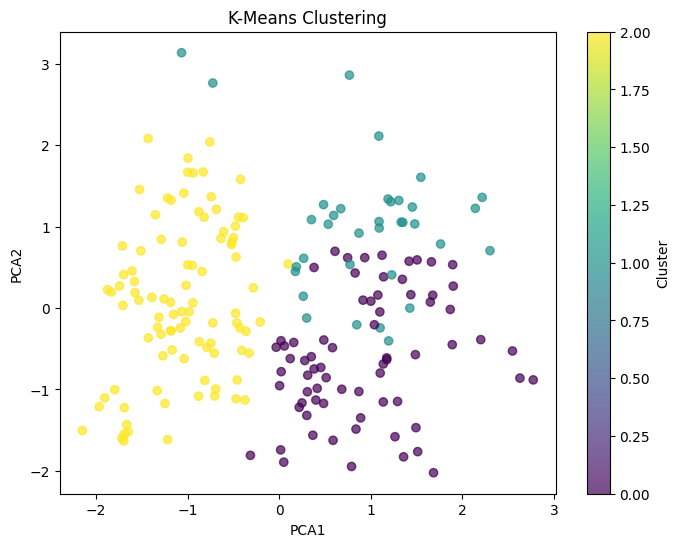

Cluster Summaries:
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         67.676056  0.394366  52.169014           46.676056   
1        167.171429  0.628571  40.228571           91.342857   
2        100.468085  0.404255  28.276596           59.585106   

         Spending Score (1-100)  
Cluster                          
0                     39.295775  
1                     20.628571  
2                     69.446809  
Cluster Sizes:
2    94
0    71
1    35
Name: count, dtype: int64
Feature Variance Across Clusters:
          CustomerID    Gender         Age  Annual Income (k$)  \
Cluster                                                          
0        1356.450704  0.242254  119.171026          253.164990   
1         502.028571  0.240336  110.416807          362.173109   
2        3468.337680  0.243423   38.331274          648.395905   

         Spending Score (1-100)  
Cluster                   

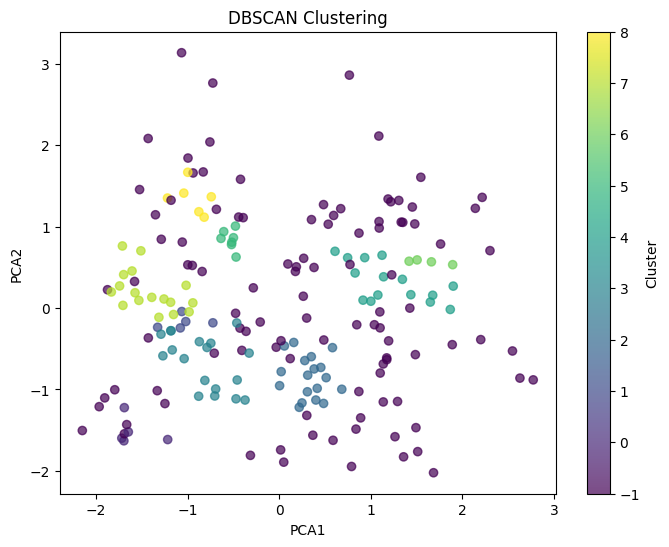

Cluster Sizes:
-1    105
 3     18
 2     18
 7     17
 4     15
 5      7
 8      6
 0      5
 1      5
 6      4
Name: count, dtype: int64

--- Hierarchical Clustering ---


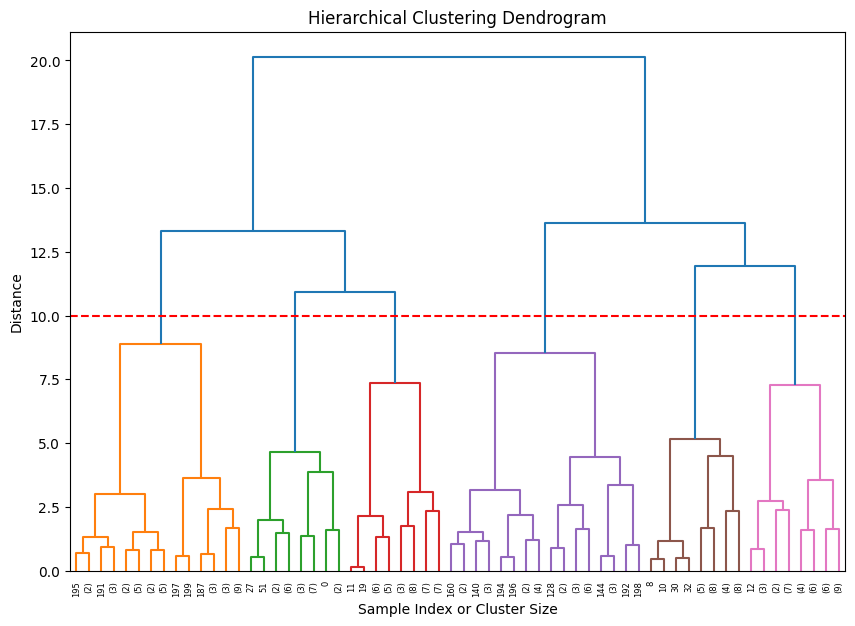

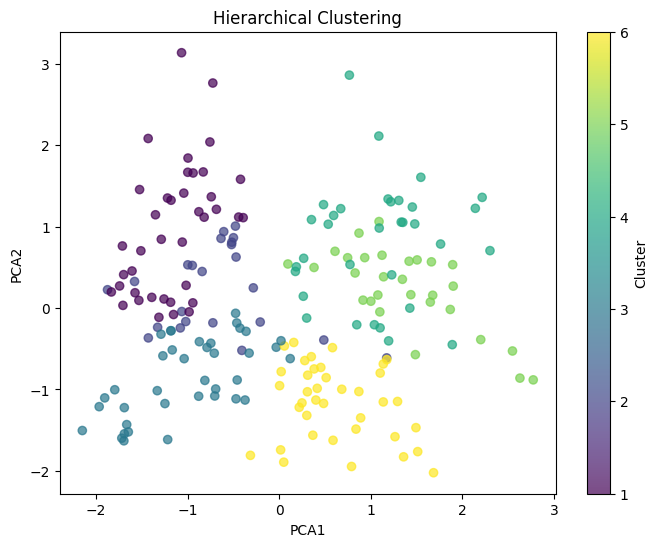

Cluster Summaries:
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
1        162.000000  0.461538  32.692308           86.538462   
2         52.217391  1.000000  24.565217           39.217391   
3         68.578947  0.000000  27.105263           46.526316   
4        166.090909  0.545455  41.454545           89.090909   
5         74.758621  1.000000  56.551724           50.034483   
6         61.210526  0.000000  49.789474           44.105263   

         Spending Score (1-100)  
Cluster                          
1                     82.128205  
2                     59.652174  
3                     58.552632  
4                     16.181818  
5                     41.344828  
6                     39.657895  
Feature Variance Across Clusters:
          CustomerID    Gender         Age  Annual Income (k$)  \
Cluster                                                          
1         520.000000  0.255061

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Load and Preprocess Data
def load_and_preprocess_data():
    """
    Loads and preprocesses the Mall Customers dataset.
    Scales the numerical features for clustering.
    """
    # Load dataset
    url = "Mall_Customers.csv"  # Ensure this file exists in your working directory
    data = pd.read_csv(url)

    # Encode Gender as numerical
    data['Gender'] = LabelEncoder().fit_transform(data['Gender'])  # Male=1, Female=0

    # Select features for clustering
    features = data[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

    # Scale numerical features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    return data, features_scaled, features

# Cluster Analysis Functions
def summarize_clusters(data, cluster_labels):
    data['Cluster'] = cluster_labels
    summary = data.groupby('Cluster').mean()
    print("Cluster Summaries:")
    print(summary)
    return summary

def plot_feature_distributions(data, feature, cluster_labels):
    data['Cluster'] = cluster_labels
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Cluster', y=feature, data=data)
    plt.title(f'{feature} Distribution Across Clusters')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.show()

def count_cluster_sizes(cluster_labels):
    cluster_sizes = pd.Series(cluster_labels).value_counts()
    print("Cluster Sizes:")
    print(cluster_sizes)
    return cluster_sizes

def analyze_feature_variance(data, cluster_labels):
    data['Cluster'] = cluster_labels
    variance = data.groupby('Cluster').var()
    print("Feature Variance Across Clusters:")
    print(variance)
    return variance

def pairwise_feature_plots(data, features, cluster_labels):
    data['Cluster'] = cluster_labels
    sns.pairplot(data, hue='Cluster', vars=features)
    plt.show()

def display_pca_loadings(pca, feature_columns):
    pca_components = pca.components_
    loadings = pd.DataFrame(pca_components, columns=feature_columns, index=[f'PC{i+1}' for i in range(len(pca_components))])
    print("PCA Component Loadings:")
    print(loadings)
    return loadings

# Visualization of Clusters Using PCA
def visualize_clusters_with_pca(features_scaled, cluster_labels, title="Clustering Visualization"):
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(features_scaled)
    plt.figure(figsize=(8, 6))
    plt.scatter(features_pca[:, 0], features_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
    plt.title(title)
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.colorbar(label='Cluster')
    plt.show()
    return pca

# Dendrogram Visualization for Hierarchical Clustering
def plot_dendrogram(linkage_matrix):
    plt.figure(figsize=(10, 7))
    dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=10)
    plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Sample Index or Cluster Size')
    plt.ylabel('Distance')
    plt.axhline(y=10, color='r', linestyle='--')
    plt.show()

# K-Means Clustering and Analysis
def analyze_kmeans(data, features_scaled):
    print("\n--- K-Means Clustering ---")
    labels_kmeans = KMeans(n_clusters=3, random_state=42).fit_predict(features_scaled)
    pca = visualize_clusters_with_pca(features_scaled, labels_kmeans, title="K-Means Clustering")
    summarize_clusters(data.copy(), labels_kmeans)
    count_cluster_sizes(labels_kmeans)
    analyze_feature_variance(data.copy(), labels_kmeans)
    return labels_kmeans, pca

# DBSCAN Clustering and Analysis
def analyze_dbscan(data, features_scaled):
    print("\n--- DBSCAN Clustering ---")
    labels_dbscan = DBSCAN(eps=0.5, min_samples=5).fit_predict(features_scaled)
    pca = visualize_clusters_with_pca(features_scaled, labels_dbscan, title="DBSCAN Clustering")
    count_cluster_sizes(labels_dbscan)
    return labels_dbscan, pca

# Hierarchical Clustering and Analysis
def analyze_hierarchical(data, features_scaled):
    print("\n--- Hierarchical Clustering ---")
    linkage_matrix = linkage(features_scaled, method='ward')
    plot_dendrogram(linkage_matrix)
    labels_hierarchical = fcluster(linkage_matrix, t=10, criterion='distance')
    pca = visualize_clusters_with_pca(features_scaled, labels_hierarchical, title="Hierarchical Clustering")
    summarize_clusters(data.copy(), labels_hierarchical)
    analyze_feature_variance(data.copy(), labels_hierarchical)
    return labels_hierarchical, pca

# Main Function
def main():
    # Load and preprocess data
    data, features_scaled, features = load_and_preprocess_data()

    # Analyze K-Means
    analyze_kmeans(data, features_scaled)

    # Analyze DBSCAN
    analyze_dbscan(data, features_scaled)

    # Analyze Hierarchical Clustering
    analyze_hierarchical(data, features_scaled)

if __name__ == "__main__":
    main()



--- DBSCAN Clustering ---

DBSCAN with eps=0.3, min_samples=5
Number of clusters: 1
Number of outliers: 194


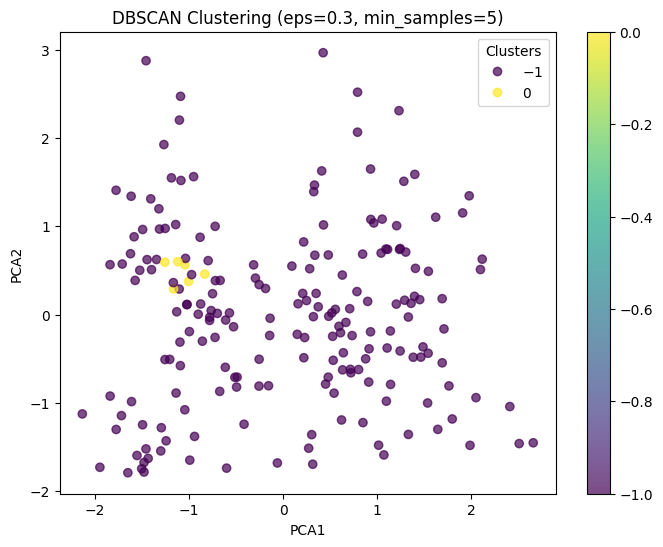


DBSCAN with eps=0.3, min_samples=10
Number of clusters: 0
Number of outliers: 200


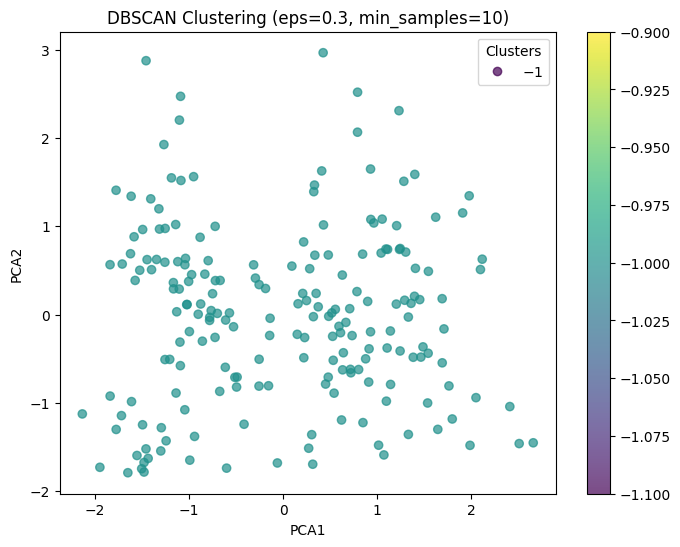


DBSCAN with eps=0.5, min_samples=5
Number of clusters: 9
Number of outliers: 105


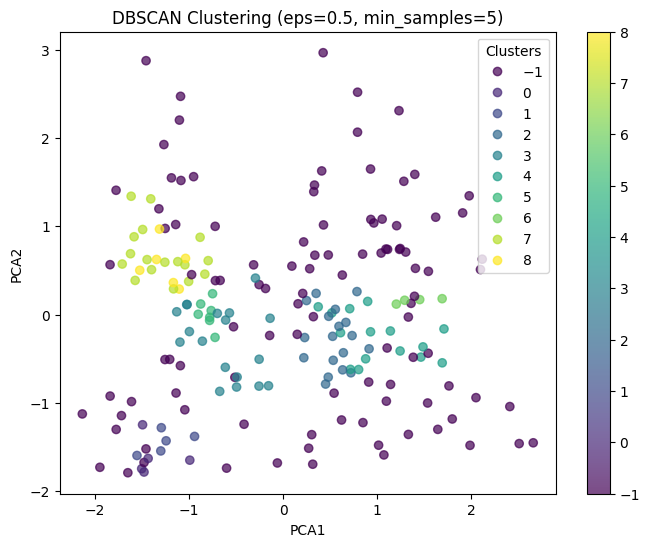


DBSCAN with eps=0.5, min_samples=10
Number of clusters: 2
Number of outliers: 178


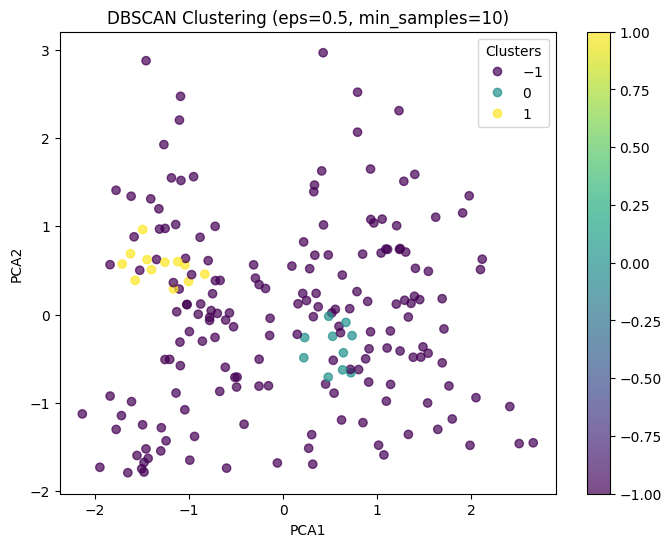


DBSCAN with eps=0.7, min_samples=5
Number of clusters: 7
Number of outliers: 37


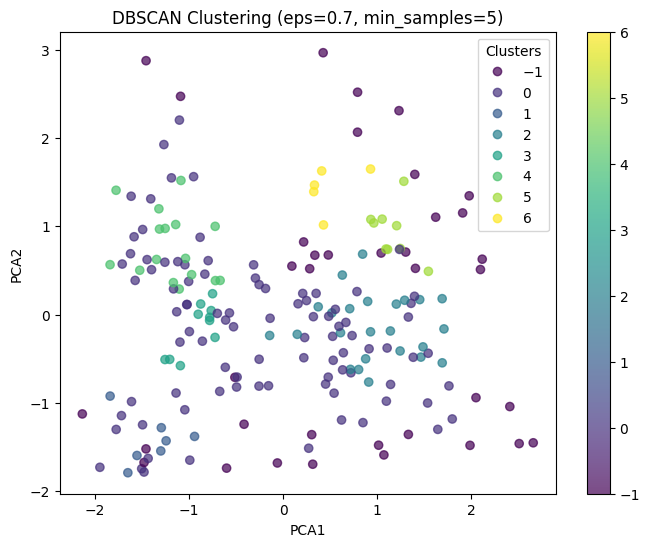


DBSCAN with eps=0.7, min_samples=10
Number of clusters: 5
Number of outliers: 106


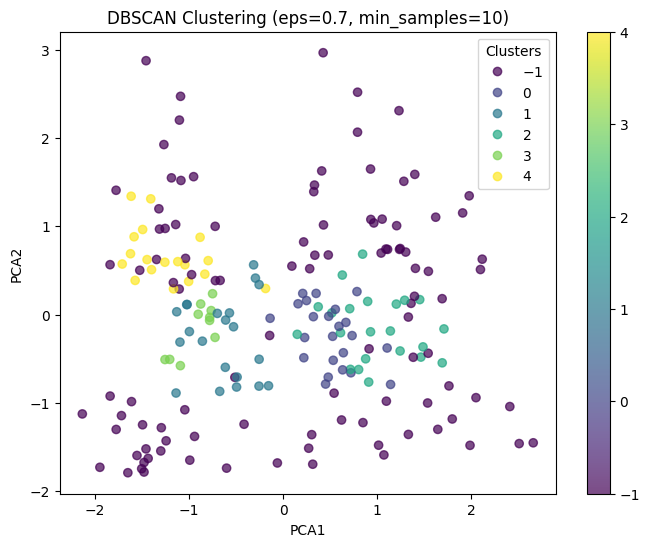


Removed 105 outliers

--- K-Means Clustering with n_clusters=3 ---


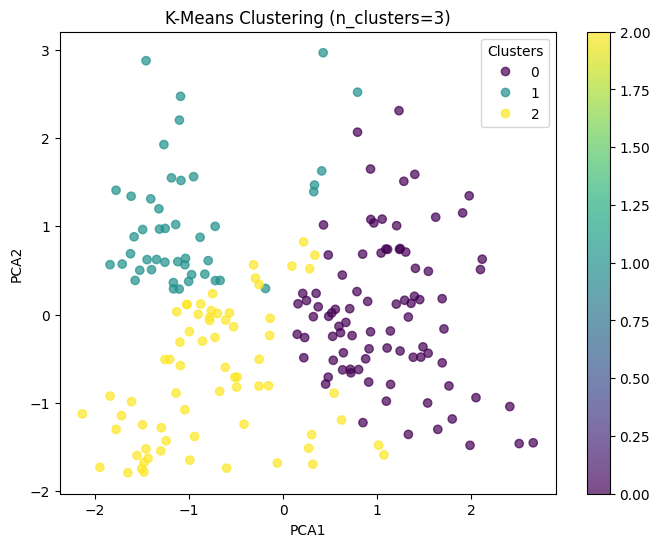

Cluster Summaries:
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         98.701149  0.471264  51.827586           59.758621   
1        164.311111  0.422222  33.422222           89.022222   
2         60.573529  0.411765  25.838235           42.750000   

         Spending Score (1-100)  
Cluster                          
0                     34.379310  
1                     75.577778  
2                     53.647059  
Cluster Sizes:
0    87
2    68
1    45
Name: count, dtype: int64
Feature Variance Across Clusters:
          CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                         
0        2536.700348  0.252072  93.655974          455.324779   
1         576.491919  0.249495  18.158586          335.931313   
2        1958.397498  0.245830  37.122695          376.996269   

         Spending Score (1-100)  
Cluster                        

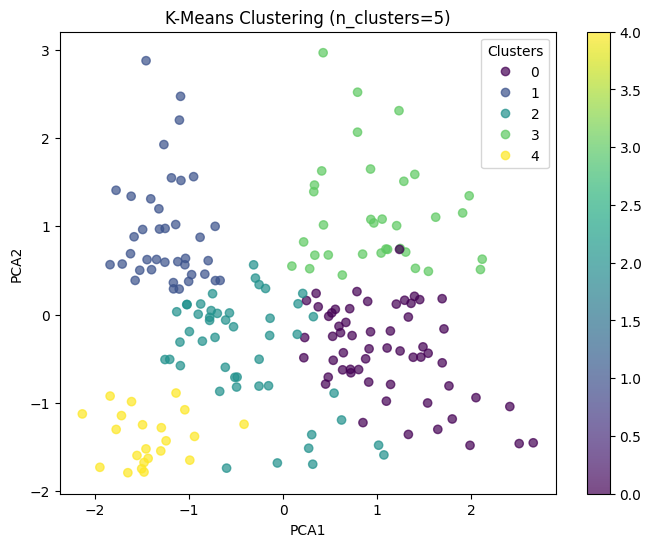

Cluster Summaries:
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         71.051724  0.431034  55.551724           48.482759   
1        162.000000  0.461538  32.692308           86.538462   
2         75.723404  0.340426  27.957447           50.000000   
3        164.529412  0.588235  41.264706           88.500000   
4         23.090909  0.409091  25.272727           25.727273   

         Spending Score (1-100)  
Cluster                          
0                     41.775862  
1                     82.128205  
2                     44.638298  
3                     16.764706  
4                     79.363636  
Cluster Sizes:
0    58
2    47
1    39
3    34
4    22
Name: count, dtype: int64
Feature Variance Across Clusters:
          CustomerID    Gender         Age  Annual Income (k$)  \
Cluster                                                          
0        1078.541137  0.249546   69.304295     

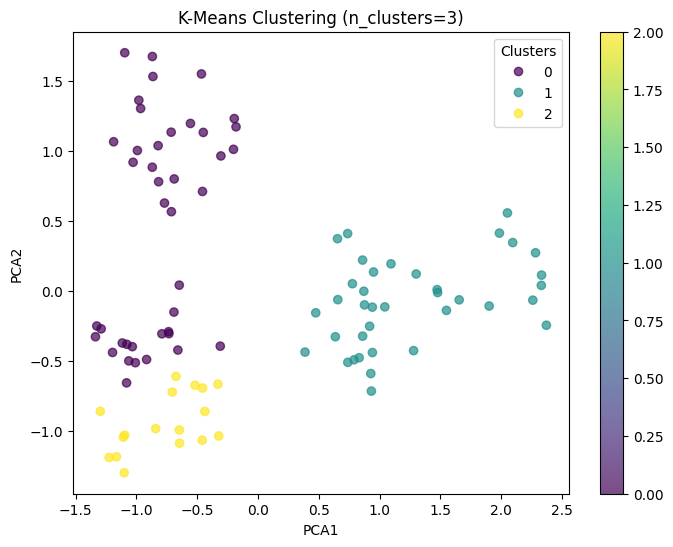

Cluster Summaries:
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0        130.707317  0.317073  28.414634           71.390244   
1         82.405405  0.513514  54.648649           53.864865   
2         32.058824  0.294118  26.764706           30.352941   

         Spending Score (1-100)  
Cluster                          
0                     68.731707  
1                     49.756757  
2                     64.235294  
Cluster Sizes:
0    41
1    37
2    17
Name: count, dtype: int64
Feature Variance Across Clusters:
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0        937.562195  0.221951  39.148780          125.843902   
1        470.858859  0.256757  67.400901           64.953453   
2        409.183824  0.220588  16.816176          122.492647   

         Spending Score (1-100)  
Cluster                          
0 

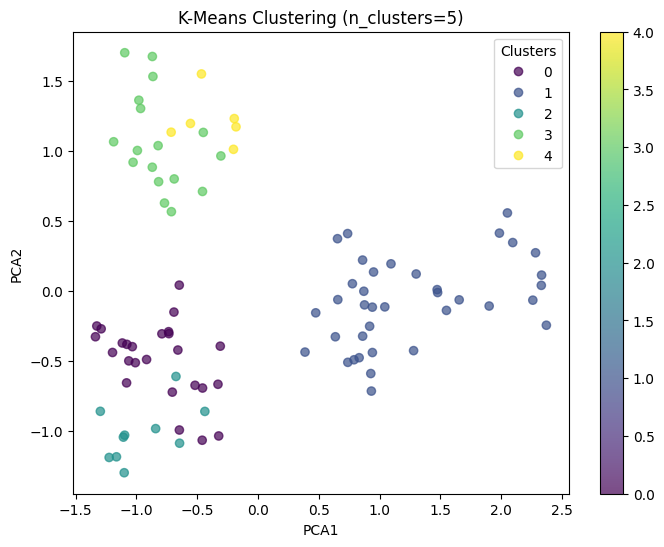

Cluster Summaries:
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         88.160000  0.280000  24.720000           55.880000   
1         82.405405  0.513514  54.648649           53.864865   
2         17.200000  0.500000  24.700000           22.000000   
3        156.352941  0.000000  31.470588           80.470588   
4        145.000000  1.000000  36.666667           76.333333   

         Spending Score (1-100)  
Cluster                          
0                     48.880000  
1                     49.756757  
2                     74.800000  
3                     81.823529  
4                     91.500000  
Cluster Sizes:
1    37
0    25
3    17
2    10
4     6
Name: count, dtype: int64
Feature Variance Across Clusters:
         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0        671.890000  0.210000  21.626667           

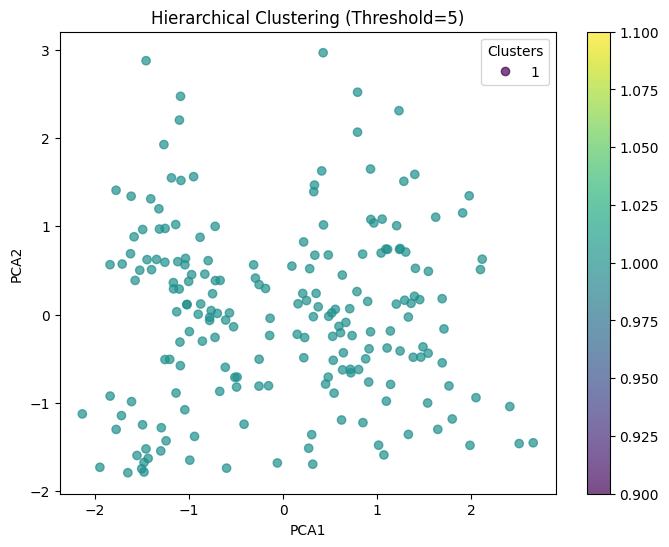

Cluster Summaries:
         CustomerID  Gender    Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                       
1             100.5    0.44  38.85               60.56                    50.2
Feature Variance Across Clusters:
         CustomerID    Gender         Age  Annual Income (k$)  \
Cluster                                                         
1            3350.0  0.247638  195.133166          689.835578   

         Spending Score (1-100)  
Cluster                          
1                    666.854271  

Cutting dendrogram at threshold 10


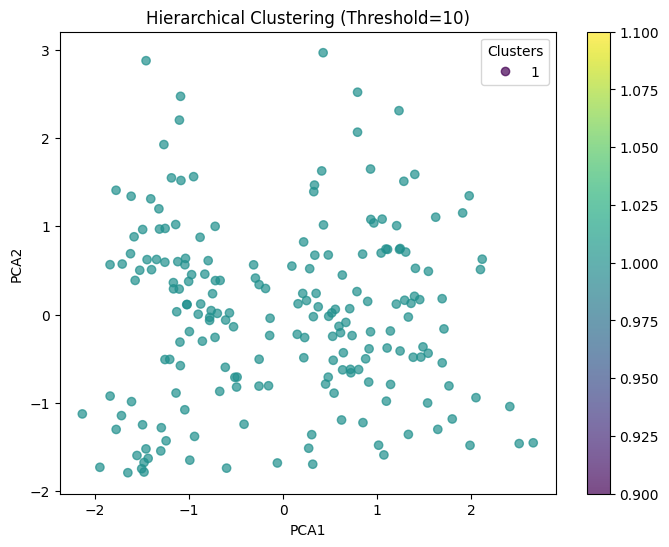

Cluster Summaries:
         CustomerID  Gender    Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                       
1             100.5    0.44  38.85               60.56                    50.2
Feature Variance Across Clusters:
         CustomerID    Gender         Age  Annual Income (k$)  \
Cluster                                                         
1            3350.0  0.247638  195.133166          689.835578   

         Spending Score (1-100)  
Cluster                          
1                    666.854271  

Cutting dendrogram at threshold 15


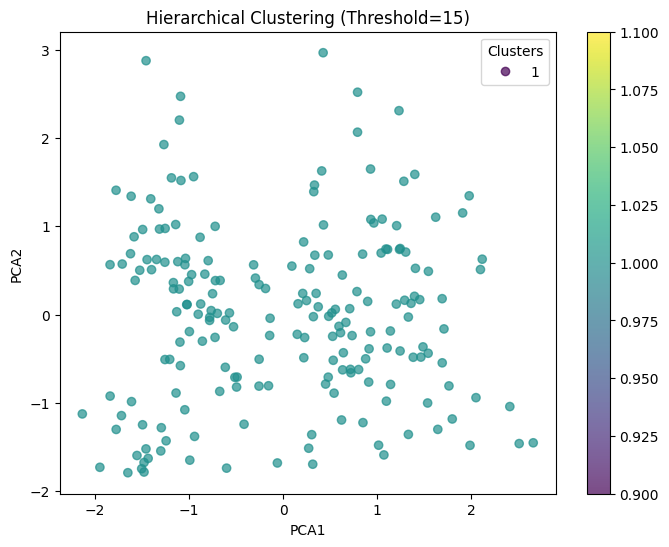

Cluster Summaries:
         CustomerID  Gender    Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                       
1             100.5    0.44  38.85               60.56                    50.2
Feature Variance Across Clusters:
         CustomerID    Gender         Age  Annual Income (k$)  \
Cluster                                                         
1            3350.0  0.247638  195.133166          689.835578   

         Spending Score (1-100)  
Cluster                          
1                    666.854271  


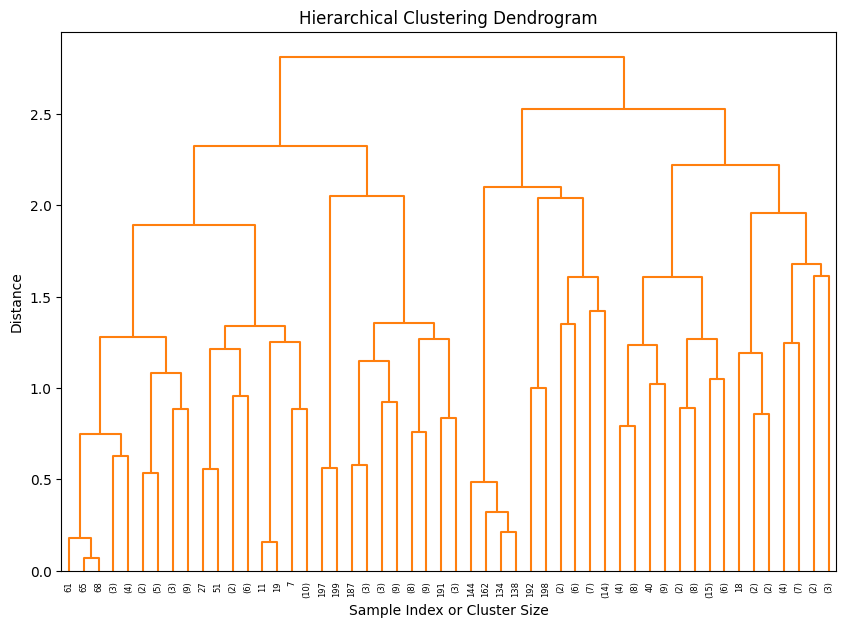

In [2]:
# mall_customer_clustering.py

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Load and Preprocess Data
def load_and_preprocess_data():
    """
    Loads and preprocesses the Mall Customers dataset.
    Scales the numerical features for clustering.
    """
    # Load dataset
    url = "Mall_Customers.csv"  # Ensure this file exists in your working directory
    data = pd.read_csv(url)

    # Encode Gender as numerical (Male=1, Female=0)
    data['Gender'] = LabelEncoder().fit_transform(data['Gender'])

    # Select features for clustering
    features = data[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

    # Scale numerical features
    scaler = StandardScaler()
    numerical_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
    features_scaled_numeric = scaler.fit_transform(features[numerical_features])
    features_scaled = pd.concat([features[['Gender']].reset_index(drop=True),
                                 pd.DataFrame(features_scaled_numeric, columns=numerical_features)],
                                axis=1)
    features_scaled_np = features_scaled.values

    return data, features_scaled_np, features_scaled

# Cluster Analysis Functions
def summarize_clusters(data, cluster_labels):
    data['Cluster'] = cluster_labels
    summary = data.groupby('Cluster').mean()
    print("Cluster Summaries:")
    print(summary)
    return summary

def count_cluster_sizes(cluster_labels):
    cluster_sizes = pd.Series(cluster_labels).value_counts()
    print("Cluster Sizes:")
    print(cluster_sizes)
    return cluster_sizes

def analyze_feature_variance(data, cluster_labels):
    data['Cluster'] = cluster_labels
    variance = data.groupby('Cluster').var()
    print("Feature Variance Across Clusters:")
    print(variance)
    return variance

def visualize_clusters_with_pca(features_scaled, cluster_labels, title="Clustering Visualization"):
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(features_scaled)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1],
                          c=cluster_labels, cmap='viridis', alpha=0.7)
    plt.title(title)
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.colorbar()
    plt.show()
    return pca

def plot_dendrogram(linkage_matrix, threshold=None):
    plt.figure(figsize=(10, 7))
    dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=threshold)
    plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Sample Index or Cluster Size')
    plt.ylabel('Distance')
    if threshold:
        plt.axhline(y=threshold, color='r', linestyle='--')
    plt.show()

# Outlier Detection and Removal using DBSCAN
def analyze_dbscan(data, features_scaled):
    print("\n--- DBSCAN Clustering ---")
    # Experiment with different eps and min_samples
    eps_values = [0.3, 0.5, 0.7]
    min_samples_values = [5, 10]

    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels_dbscan = dbscan.fit_predict(features_scaled)
            n_outliers = np.sum(labels_dbscan == -1)
            n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
            print(f"\nDBSCAN with eps={eps}, min_samples={min_samples}")
            print(f"Number of clusters: {n_clusters}")
            print(f"Number of outliers: {n_outliers}")
            # Visualize clusters and outliers
            visualize_clusters_with_pca(features_scaled, labels_dbscan,
                                        title=f"DBSCAN Clustering (eps={eps}, min_samples={min_samples})")
    # Use default parameters for further analysis
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    labels_dbscan = dbscan.fit_predict(features_scaled)
    return labels_dbscan

def remove_outliers(data, features_scaled, labels_dbscan):
    data_dbscan = data.copy()
    data_dbscan['Cluster'] = labels_dbscan
    # Filter out outliers labeled as -1
    data_cleaned = data_dbscan[data_dbscan['Cluster'] != -1].reset_index(drop=True)
    features_cleaned = features_scaled[data_dbscan['Cluster'] != -1]
    print(f"\nRemoved {len(data) - len(data_cleaned)} outliers")
    return data_cleaned, features_cleaned

# K-Means Clustering and Analysis
def analyze_kmeans(data, features_scaled, n_clusters_list=[3]):
    from sklearn.cluster import KMeans
    results = {}
    for n_clusters in n_clusters_list:
        print(f"\n--- K-Means Clustering with n_clusters={n_clusters} ---")
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels_kmeans = kmeans.fit_predict(features_scaled)
        pca = visualize_clusters_with_pca(features_scaled, labels_kmeans,
                                          title=f"K-Means Clustering (n_clusters={n_clusters})")
        summarize_clusters(data.copy(), labels_kmeans)
        count_cluster_sizes(labels_kmeans)
        analyze_feature_variance(data.copy(), labels_kmeans)
        results[n_clusters] = labels_kmeans
    return results

# Hierarchical Clustering and Analysis
def analyze_hierarchical(data, features_scaled, method='average'):
    print(f"\n--- Hierarchical Clustering using {method.capitalize()} Linkage ---")
    linkage_matrix = linkage(features_scaled, method=method)
    thresholds = [5, 10, 15]
    for threshold in thresholds:
        print(f"\nCutting dendrogram at threshold {threshold}")
        labels_hierarchical = fcluster(linkage_matrix, t=threshold, criterion='distance')
        visualize_clusters_with_pca(features_scaled, labels_hierarchical,
                                    title=f"Hierarchical Clustering (Threshold={threshold})")
        summarize_clusters(data.copy(), labels_hierarchical)
        analyze_feature_variance(data.copy(), labels_hierarchical)
    # Plot dendrogram with last threshold
    plot_dendrogram(linkage_matrix, threshold=thresholds[-1])
    return labels_hierarchical

# Main Function
def main():
    # Load and preprocess data
    data, features_scaled_np, features_scaled = load_and_preprocess_data()

    # Analyze DBSCAN and remove outliers
    labels_dbscan = analyze_dbscan(data, features_scaled_np)
    data_cleaned, features_cleaned = remove_outliers(data, features_scaled_np, labels_dbscan)

    # Analyze K-Means on Original Data
    analyze_kmeans(data, features_scaled_np, n_clusters_list=[3, 5])

    # Analyze K-Means on Cleaned Data
    analyze_kmeans(data_cleaned, features_cleaned, n_clusters_list=[3, 5])

    # Analyze Hierarchical Clustering
    analyze_hierarchical(data, features_scaled_np, method='average')

if __name__ == "__main__":
    main()

# Observations

## 1. DBSCAN

### a. How many outliers were detected in each dataset? What do these outliers represent?

- **eps=0.3, min_samples=5:**
  - Number of clusters: 1
  - Number of outliers: 194

- **eps=0.3, min_samples=10:**
  - Number of clusters: 0
  - Number of outliers: 200 (All data points are considered outliers)

- **eps=0.5, min_samples=5:**
  - Number of clusters: 9
  - Number of outliers: 105

- **eps=0.5, min_samples=10:**
  - Number of clusters: 2
  - Number of outliers: 178

- **eps=0.7, min_samples=5:**
  - Number of clusters: 7
  - Number of outliers: 37

- **eps=0.7, min_samples=10:**
  - Number of clusters: 5
  - Number of outliers: 106

**Outlier Analysis:**

- With `eps=0.5` and `min_samples=5`, the algorithm identified 105 outliers in the Mall Customers dataset of 200 entries.
- The outliers represent customers whose behaviors are significantly different from the majority. They might have unique combinations of age, income, and spending score, placing them far from dense regions in the feature space.
- These outliers could be high-income low-spending individuals, very young or old customers with unusual spending patterns, or data points with rare attribute combinations.

### b. How did changing eps and min_samples affect the clustering results?

**Effect of eps:**

- **Decrease in eps (from 0.7 to 0.3):**
  - At `eps=0.3`, `min_samples=5`:
    - Number of clusters dropped to 1 (or none when `min_samples=10`).
    - Outliers increased dramatically to 194 (or 200), meaning almost all points are considered outliers.
    - The smaller eps made the neighborhood radius too small, so very few points were close enough to form clusters.

- **Increase in eps (from 0.3 to 0.7):**
  - At `eps=0.7`, `min_samples=5`:
    - Number of clusters increased to 7.
    - Outliers decreased to 37.
    - Larger eps included more points within the neighborhood radius, allowing more clusters to form and fewer outliers.

**Effect of min_samples:**

- **Increase in min_samples:**
  - With higher `min_samples`, more points are required to form a cluster, leading to fewer clusters and more outliers.
  - At `eps=0.5`, `min_samples=10`:
    - Number of clusters decreased to 2.
    - Outliers increased to 178.

**Observation:**

- Optimal balance achieved around `eps=0.7` and `min_samples=5`, with 7 clusters and 37 outliers.

## 2. K-Means

### a. How did removing outliers affect the K-Means clusters?

**Before Removing Outliers (Original Data):**

- `n_clusters=3`:
  - Cluster Sizes: 94, 71, 35
  - Variance within clusters was higher, indicating less compactness.
  - Cluster Summaries Indicate:
    - Clusters are influenced by extreme values due to outliers.
    - For instance, Cluster 2 had a high 'Spending Score' mean of approximately 69.45.

**After Removing Outliers (Cleaned Data):**

- Removed 105 Outliers
- `n_clusters=3`:
  - Cluster Sizes: 87, 45, 68
  - Variance within clusters decreased significantly.
  - Clusters became more balanced and compact.

**Observation:**

- Removal of outliers led to clusters that are more representative of the main patterns in the data.
- The clusters are less skewed and have lower intracluster variance.

### b. Which n_clusters value produced the most meaningful clusters?

- **n_clusters=3:**
  - After Outlier Removal:
    - Clusters are larger and more balanced (87, 45, 68).
    - However, broad clusters may not capture finer distinctions between customer types.

- **n_clusters=5:**
  - After Outlier Removal:
    - Clusters have sizes: 58, 47, 39, 34, 22.
    - Clusters provide more granularity.
    - Cluster Insights:
      - Cluster 1: High-income young customers with high spending scores.
      - Cluster 3: High-income older customers with low spending scores.
      - Cluster 4: Low-income young customers with high spending scores.
    - Variance within clusters is lower compared to `n_clusters=3`.

**Conclusion:**

- `n_clusters=5` produced more meaningful clusters, allowing for detailed customer segmentation suitable for targeted marketing strategies.

## 3. Hierarchical Clustering

### a. How does the dendrogram reveal relationships between clusters?

**Mall Customers Dataset:**

- Using Average Linkage:
  - Cutting the dendrogram at thresholds of 5, 10, and 15 all resulted in a single cluster.
  - The dendrogram suggests that customers are gradually merged into one cluster due to similar average distances.
  - The lack of distinct clusters at practical thresholds may indicate that average linkage is not capturing the clustering structure well in this dataset.

### b. What happens when the threshold for cutting the dendrogram is too high or too low?

- **Threshold Too High:**
  - Cutting at high thresholds (e.g., 15) resulted in all data points being assigned to a single cluster.
  - This provides no useful segmentation for analysis or marketing purposes.

- **Threshold Too Low:**
  - Mall Customers Dataset:
    - Cutting at very low thresholds would create many small clusters or singleton clusters.
    - The clusters may be too specific, making it difficult to derive actionable insights.

## 4. General Comparison

### a. Which clustering method worked best for each dataset? Why?

**Best Method: K-Means Clustering after Outlier Removal**

**Reasons:**

- K-Means provided clear, interpretable clusters that align with customer segments.
- After removing outliers, clusters were more compact and meaningful.
- `n_clusters=5` allowed segmentation into distinct groups based on age, income, and spending score.

**DBSCAN:**

- Helpful for outlier detection but less effective for clustering due to sensitivity to parameter selection.
- High number of outliers under certain parameters.

### b. How would you use these clusters in a real-world scenario (e.g., marketing)?

**Targeted Marketing:**

- Develop marketing campaigns tailored to each cluster.
- Cluster 1 (High Income, High Spending Score):
  - Offer premium products, exclusive deals, or loyalty programs.
- Cluster 4 (Low Income, High Spending Score):
  - Promote affordable luxury or discounts to encourage continued patronage.

**Customer Relationship Management:**

- Personalize communications and engagements based on cluster characteristics.
- Enhance customer experience to increase satisfaction and retention.

**Product Placement and Store Layout:**

- Arrange products and services to appeal to the dominant customer segments identified.

**Resource Allocation:**

- Allocate marketing budget and resources efficiently by focusing on clusters with the highest potential ROI.

#**Comparison of Effectiveness of Each Clustering Method:**

- **DBSCAN:**
  - Effective in outlier detection.
  - The high number of outliers with certain parameters indicates that the dataset may not have clear density-based clusters.
  - Less suitable for the main clustering task due to sensitivity to eps and min_samples.

- **K-Means Clustering:**
  - Most effective method after outlier removal.
  - Provided clear, actionable clusters aligning with marketing needs.
  - Clusters are easy to interpret and implement in business strategies.

- **Hierarchical Clustering:**
  - Less effective with average linkage.
  - Dendrogram did not reveal distinct clusters at practical thresholds.
  - Alternate linkage methods (like Ward) might yield better results but were not tested in the outputs provided.

**Conclusion:** K-Means was the best clustering method due to its simplicity, interpretability, and alignment with marketing objectives.
